# S04a: The $t$-Test

Originally, the bell-curve itself was utilized for basic statistical inquiry. The $z$ statistic was found to have a couple of issues:

- The $z$ statistic is brittle rather than robust.
- The $z$ statistic required larger sample sizes to produce reasonable accuracy. 

## William Sealy Gossett and the $t$-Test

The $t$-test has replaced the $z$-test due to the work of William Sealy Gossett who worked for the Guiness Brewery in Dublin, Ireland. Recognizing the shortfalls of the traditional $z$-test, he created a series of bell-shaped curves that, as sample size increases, coverge the $z$ distribution. This update produced the following improvements:

- The $t$ statistic is robust.
- The $t$ statistic is accurate even with small sample sizes.

In practice, the $z$-test is almost never used in modern statistics.

## Assumptions of the $t$-Test

Three standard assumptions of the $t$-test keep us using it only when the data are appropriate for it.

1. Normality
2. Independence
3. Homogeneity of the Variances

The only one that we check on statistically is the normality assumption which says that we must have evidence the data were drawn from a normal (bell-shaped) distribution.

### Data Checks for the $t$-Test

To **verify the assumptions**, we will construct both a **density plot** and a **boxplot**. In the *density plot*, we seek evidence of a bell-shape indicating the data were, in fact, drawn from a normal distribution. 

### Outliers and the $t$-Test

For the *boxplot*, we hope to find no outliers. For $n\geq 40$, the robustness of the $t$ statistic will produce accurate results. For small sample sizes where $n<40$, outliers can result in loss of accuracy to the point the results are spurious.

## Example 1

In the **personality** data frame, we have the column entitled **HSAG** which stands for *aggressive humor*. Aggressive humor is comprised of sarcasm and putdowns and can be quite dark. In prior research, biological men were found to use more aggressive humor than biological women, and young persons were found to use more aggressive than older persons. Conduct the test at the $\alpha = 0.05$ level.

### Research Question

For males age 19 or younger, conduct a hypothesis test this group has, on average, higher aggressive humor scores than the overall UNG population which is known to have an average HSAG score of $\mu=29$.

### Hypothesis

$$\begin{align}H_0 : \mu = 29\\H_0 : \mu > 29\end{align}$$

In words, the null hypothesis is that the average HSAG for young males is 29 while the alternative hypothesis states that the average for them is higher than 29.

### Loading the Data and Subsetting the Data Frame

After loading the **personality** data frame, we have to subset with 2 criteria: *biological sex* is male plus *age* is less than or equal to 19.

The required subset data frame is called **ym** for "young males," and the data frame has 36 rows or individual students who meet these criteria.

In [17]:
pers <- read.csv('https://faculty.ung.edu/rsinn/data/personality.csv')
temp <- subset(pers,Sex == 'M' & Age <= 19)
ym <- temp$HSAG

We will use the <span style = 'color:blue;font-weight:bold'>\$ method</span> to extract the column **HSAG** which contains the aggressive humor scores.

### Data Checks

We will compute the descriptive statistics and produce both a density plot and a boxplot. We will use the same techniques and functions we learned in earlier sections. The code for descriptives was found in the [course notes](https://straightdraw.github.io/probstat/S1.html).

In [21]:
cat('The standard descriptives for Young Male Aggressive Humor:\n   Mean = ', round(mean(ym),2),
    '\n   Standard Deviation = ', round(sd(ym),2),
    '\n   Sample Size = ', length(ym),
    '\n\nThe 5-number summary Young Male Aggressive Humor:')
summary(ym)

The standard descriptives for Young Male Aggressive Humor:
   Mean =  32.25 
   Standard Deviation =  6.06 
   Sample Size =  12 

The 5-number summary Young Male Aggressive Humor:

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  19.00   29.00   33.00   32.25   35.50   41.00 

In [22]:
### Data Checks and Graphics

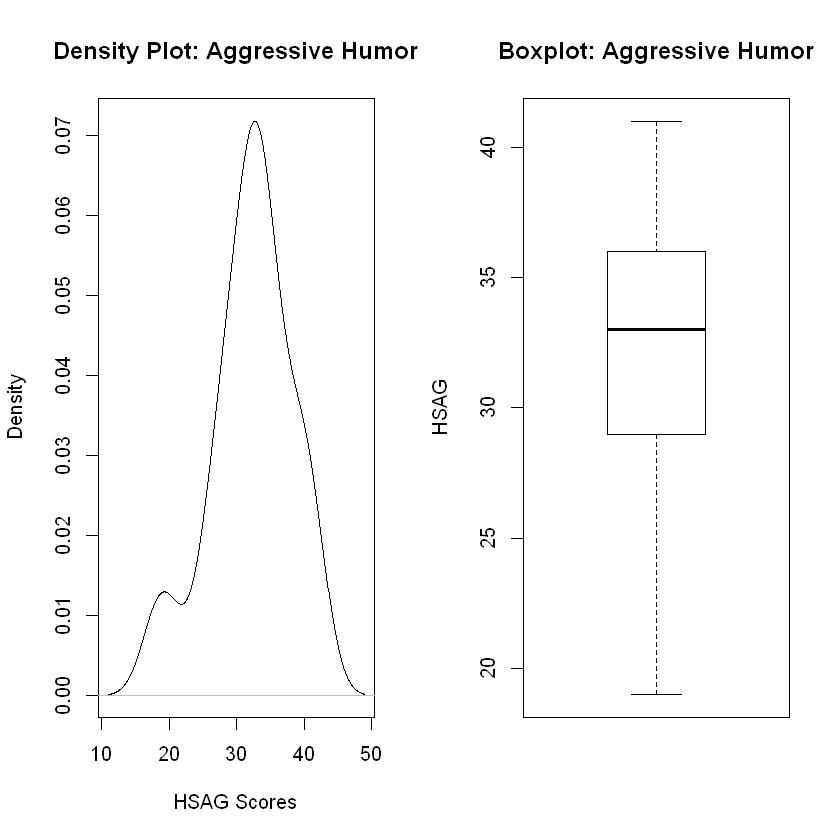

In [23]:
# Using layout() and matrix() to create grid.
layout(matrix(c(1,2), ncol = 2), lcm(9))
plot(density(ym), main = 'Density Plot: Aggressive Humor', xlab = 'HSAG Scores')
boxplot(ym, main = 'Boxplot: Aggressive Humor', ylab = 'HSAG')

The data check is complete showing that we have approximately bell-shaped data. Our conclusion is that these data were likely drawn from a normal (bell-shaped) distribution, as required. There are no outliers, yet we see a slight skew to the left.

<span style = 'color:blue; font-weight:bold'>These data are appropriate for $t$ procedures.</span>

### Running the Test

Let's conduct the **t.test()** below.

In [24]:
t.test(ym, mu = 29, alternative = 'g')


	One Sample t-test

data:  ym
t = 1.8571, df = 11, p-value = 0.04512
alternative hypothesis: true mean is greater than 29
95 percent confidence interval:
 29.1072     Inf
sample estimates:
mean of x 
    32.25 


### Reporting Out

Because $p = 0.04512 < 0.05 = \alpha$, we reject the null. We thus have evidence that the average HSAG scores for young males is greater than the overall average for UNG students in Dahlonega.

## Example 2: Playfulness

The variable **Adult Playfulness** in the *personality* data frame tracks the childlike qualities of a person who may enjoy splashing through puddles, singing or dancing at odd moments, and dressing up or dressing down just for the fun of it. The Playfulness scores at UNG Dahlonega have the $N(127,18)$ distribution. Test at the $\alpha=0.5$ level whether biological females aged 20 and younger have a higher average Playfulness score than their counterparts.

The subsetting necessary to create the "young females" **yf** subset from the personality data frame is given below.

In [1]:
pers <- read.csv('https://faculty.ung.edu/rsinn/data/personality.csv')
temp <- subset(pers,Sex == 'F' & Age <= 20)
yf <- temp$Play

## Example 3: Skyscrapers

The data frame **skyscrapers** lists the tallest buildings in the United States. The heights of these buildings have the $N(136, 50)$ distribution where the units are in meters. Test at the $\alpha = 0.025$ level whether the average height of Atlanta skyscrapers is taller than the average height for buildings in this data frame.

In [13]:
sky <- read.csv('https://faculty.ung.edu/rsinn/data/skyscrapers_v2.csv')
atl_temp <- subset(sky, city == 'Atlanta')
atl <- atl_temp$height